In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

Explained Variance Ratio: [0.72962445 0.22850762]
Total Variance Explained: 0.9581320720000166


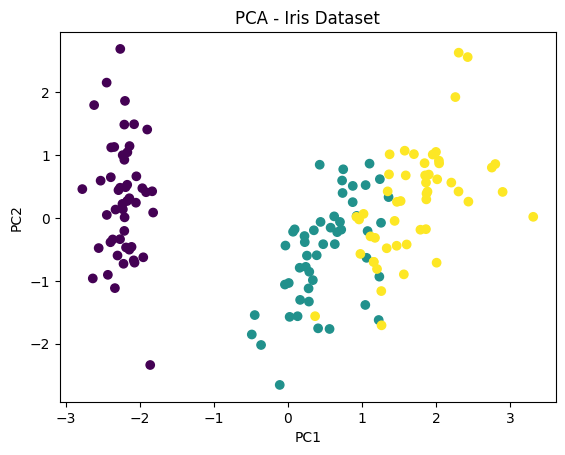

In [2]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
import numpy as np

# Load Iris
iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['species'] = iris.target

# Scale first!
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[iris.feature_names])

# Apply PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Explained variance
print("Explained Variance Ratio:", pca.explained_variance_ratio_)
print("Total Variance Explained:", sum(pca.explained_variance_ratio_))

# Visualize
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df['species'])
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA - Iris Dataset")
plt.show()

Cumulative Variance: [0.72962445 0.95813207 0.99482129 1.        ]


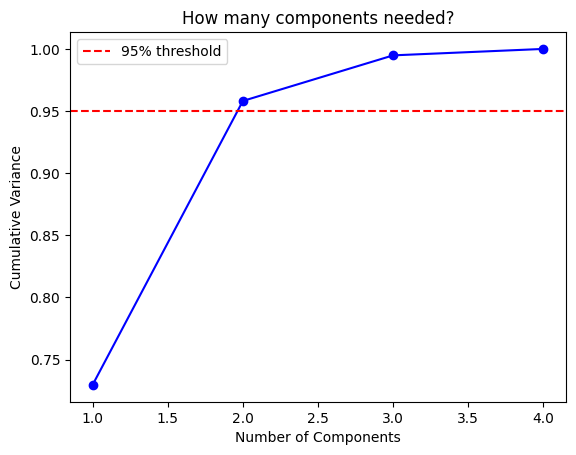

In [3]:
# How many components to keep?
pca_full = PCA()
pca_full.fit(X_scaled)

# Cumulative variance
cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)
print("Cumulative Variance:", cumulative_variance)

# Plot
plt.plot(range(1, len(cumulative_variance)+1), 
         cumulative_variance, 'bo-')
plt.axhline(y=0.95, color='r', linestyle='--', 
            label='95% threshold')
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Variance")
plt.title("How many components needed?")
plt.legend()
plt.show()